In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr

In [2]:
data = {
    "Student": [
        "Asha", "Rahul", "Priya", "Arjun",
        "Sneha", "Rohan", "Ananya", "Vikash",
        "Neha", "Karan", "Pooja", "Amit"
    ],

    "Study_Hours": [
        2, 4, 5, 6, 3, 7, 8, 4, 6, 5, 3, 7
    ],

    "Attendance": [
        70, 80, 85, 90, 75, 95, 98, 82, 88, 79, 72, 93
    ],

    "Assignment_Score": [
        65, 72, 80, 85, 68, 92, 95, 75, 84, 78, 70, 89
    ],

    "Exam_Score": [
        62, 70, 78, 88, 65, 94, 96, 73, 86, 80, 67, 91
    ]
}

df = pd.DataFrame(data)


In [3]:
df

,Student,Study_Hours,Attendance,Assignment_Score,Exam_Score
0,Asha,2,70,65,62
1,Rahul,4,80,72,70
2,Priya,5,85,80,78
3,Arjun,6,90,85,88
4,Sneha,3,75,68,65
5,Rohan,7,95,92,94
6,Ananya,8,98,95,96
7,Vikash,4,82,75,73
8,Neha,6,88,84,86
9,Karan,5,79,78,80


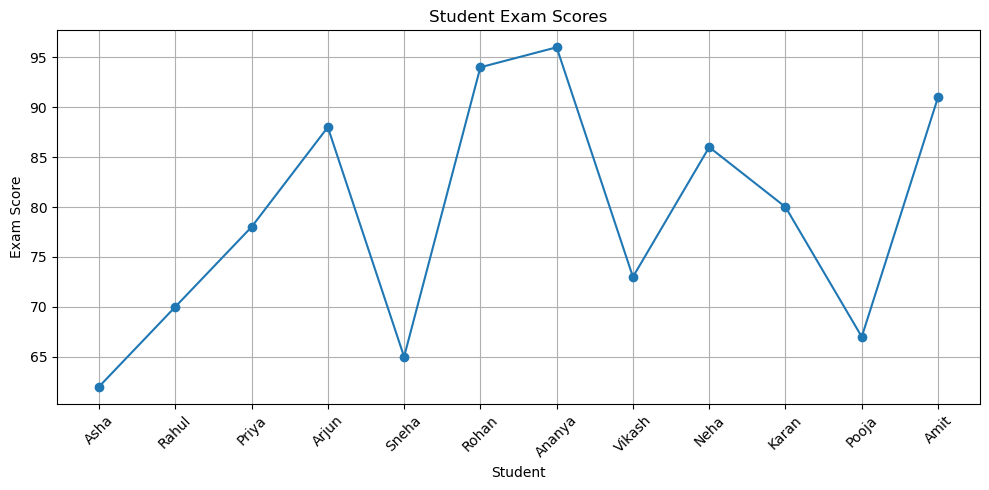

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["Student"],
    df["Exam_Score"],
    marker="o"
)

plt.title("Student Exam Scores")
plt.xlabel("Student")
plt.ylabel("Exam Score")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

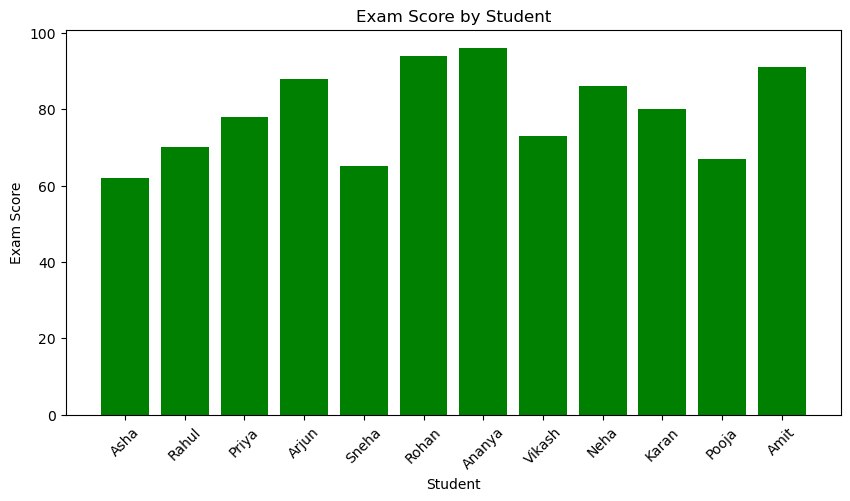

In [11]:
plt.figure(figsize=(10, 5))
width = 0.3

plt.bar(
    df["Student"],
    df["Exam_Score"],
    color="green"
)

plt.title("Exam Score by Student")
plt.xlabel("Student")
plt.ylabel("Exam Score")

plt.xticks(rotation=45)

plt.show()

In [12]:
def get_performance(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Good"
    elif score >= 60:
        return "Average"
    else:
        return "Poor"

df["Performance"] = df["Exam_Score"].apply(get_performance)

df

,Student,Study_Hours,Attendance,Assignment_Score,Exam_Score,Performance
0,Asha,2,70,65,62,Average
1,Rahul,4,80,72,70,Average
2,Priya,5,85,80,78,Good
3,Arjun,6,90,85,88,Good
4,Sneha,3,75,68,65,Average
5,Rohan,7,95,92,94,Excellent
6,Ananya,8,98,95,96,Excellent
7,Vikash,4,82,75,73,Average
8,Neha,6,88,84,86,Good
9,Karan,5,79,78,80,Good


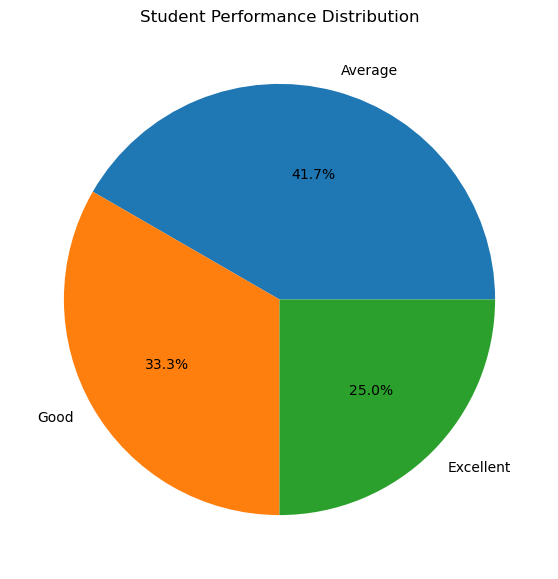

In [13]:
performance_count = df["Performance"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    performance_count,
    labels=performance_count.index,
    autopct="%1.1f%%"
)

plt.title("Student Performance Distribution")

plt.show()

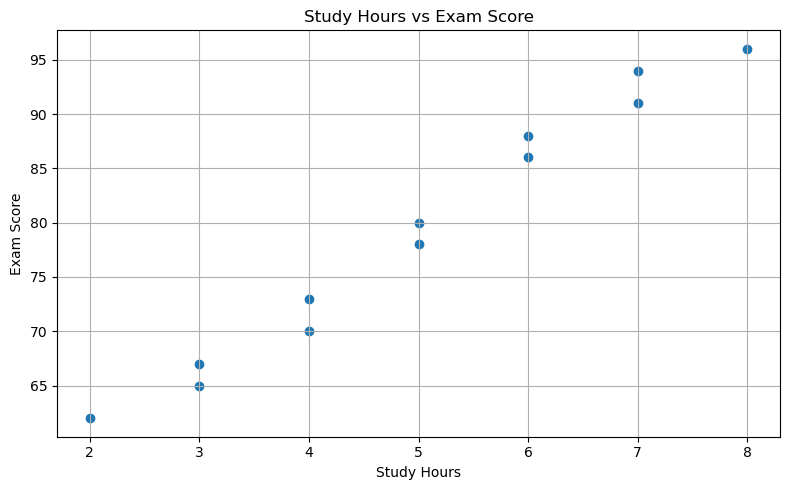

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Exam_Score"]
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.grid(True)
plt.tight_layout()
plt.show()

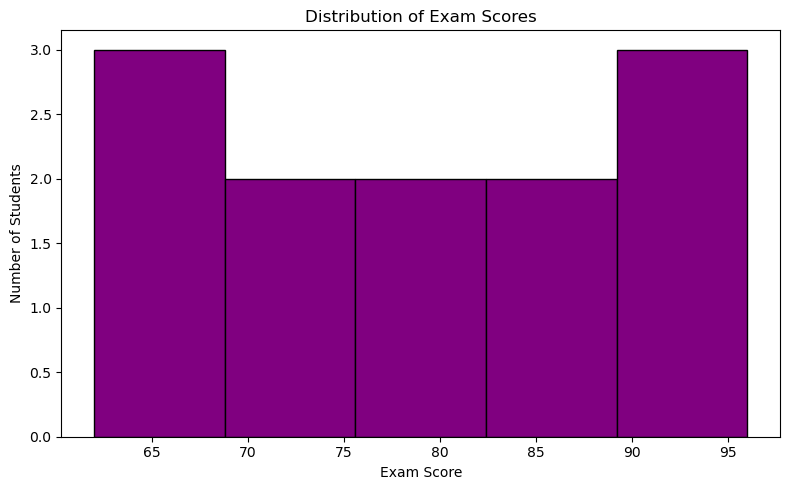

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Exam_Score"],
    bins=5,
    color='purple', edgecolor='black'
)
 
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

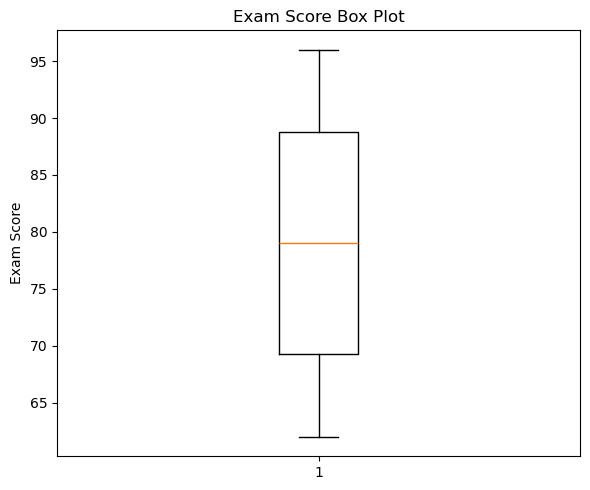

In [24]:
plt.figure(figsize=(6, 5))

plt.boxplot(df["Exam_Score"])

plt.title("Exam Score Box Plot")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

In [27]:
def show_chart(chart_type):

    plt.close("all")

    # Create figure
    fig = plt.figure(figsize=(11, 6))

    if chart_type == "Line Plot":

        plt.plot(
            df["Student"],
            df["Exam_Score"],
            marker="o",
            linewidth=2,
            markersize=8
        )

        plt.title(
            "Student Exam Scores",
            fontsize=18,
            fontweight="bold"
        )
        plt.xlabel("Student", fontsize=12)
        plt.ylabel("Exam Score", fontsize=12)

        plt.grid(True, linestyle="--", alpha=0.5)
        plt.xticks(rotation=45)

    elif chart_type == "Bar Chart":

        plt.bar(
            df["Student"],
            df["Exam_Score"],
            color="green",
            edgecolor="black",
            alpha=0.8
        )

        plt.title(
            "Exam Score by Student",
            fontsize=18,
            fontweight="bold"
        )
        plt.xlabel("Student", fontsize=12)
        plt.ylabel("Exam Score", fontsize=12)

        plt.xticks(rotation=45)
        plt.grid(axis="y", linestyle="--", alpha=0.4)

    elif chart_type == "Pie Chart":

        performance_count = df["Performance"].value_counts()

        plt.pie(
            performance_count,
            labels=performance_count.index,
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2}
        )

        plt.title(
            "Student Performance Distribution",
            fontsize=18,
            fontweight="bold"
        )

    elif chart_type == "Scatter Plot":

        plt.scatter(
            df["Study_Hours"],
            df["Exam_Score"],
            s=100,
            alpha=0.8,
            edgecolors="black"
        )

        plt.title(
            "Study Hours vs Exam Score",
            fontsize=18,
            fontweight="bold"
        )
        plt.xlabel("Study Hours", fontsize=12)
        plt.ylabel("Exam Score", fontsize=12)

        plt.grid(True, linestyle="--", alpha=0.5)

    elif chart_type == "Histogram":

        plt.hist(
            df["Exam_Score"],
            bins=5,
            color="purple",
            edgecolor="black",
            alpha=0.8
        )

        plt.title(
            "Distribution of Exam Scores",
            fontsize=18,
            fontweight="bold"
        )
        plt.xlabel("Exam Score", fontsize=12)
        plt.ylabel("Number of Students", fontsize=12)

        plt.grid(axis="y", linestyle="--", alpha=0.4)

    elif chart_type == "Box Plot":

        plt.boxplot(
            df["Exam_Score"],
            patch_artist=True
        )

        plt.title(
            "Exam Score Box Plot",
            fontsize=18,
            fontweight="bold"
        )
        plt.ylabel("Exam Score", fontsize=12)

        plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()

    return fig

In [28]:
import gradio as gr

with gr.Blocks(
    title="Student Performance Visual Explorer"
) as demo:

    gr.Markdown(
        """
        # 🎓 Student Performance Visual Explorer

        ### 📊 Analyze student performance using interactive charts

        Select a chart from the dropdown below to explore
        study hours, attendance, assignment scores and exam scores.
        """
    )

    gr.Markdown("---")

    with gr.Row():

        with gr.Column(scale=1):

            gr.Markdown("### 📌 Select Visualization")

            chart_dropdown = gr.Dropdown(
                choices=[
                    "Line Plot",
                    "Bar Chart",
                    "Pie Chart",
                    "Scatter Plot",
                    "Histogram",
                    "Box Plot"
                ],
                value="Bar Chart",
                label="Choose Plot Type",
                info="Select a visualization to analyze student performance."
            )

            generate_button = gr.Button(
                "📊 Generate Chart",
                variant="primary"
            )

        with gr.Column(scale=2):

            gr.Markdown("### 📈 Visualization")

            plot_output = gr.Plot(
                label="Student Performance Chart"
            )

    generate_button.click(
        fn=show_chart,
        inputs=chart_dropdown,
        outputs=plot_output
    )

    gr.Markdown("---")

    gr.Markdown(
        """
        ### 📚 Project Information

        **Dataset:** Student Performance

        **Technologies:** Python • Pandas • Matplotlib • Gradio

        **Visualizations:** Line Plot • Bar Chart • Pie Chart •
        Scatter Plot • Histogram • Box Plot
        """
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
